# Hyperbolic Tangent Polynomial Approximation in Multi-precision Arithmetic

This notebook computes the polynomial coefficients of an approximation to the hyperbolic tangent in multi-precision arithmetic.


In [1]:
import cupy as cp
from datetime import datetime
from mpmath import exp, factorial, pi, polylog, mp
import numpy as np
import matplotlib.pyplot as plt
import pickle

## Define Helpful Functions

In [2]:
def polyval_gpu(p, e, x):
    """Evaluates a polynomial

    Params:
    p - The coefficients of the polynomial, cupy vector
    e - The the exponents of the polynomial, cupy vector
    x - The independent variable, cupy vector

    Returns:
    result -- The evaluated polynomial
    """

    result = cp.zeros(cp.shape(x))

    for coef, exp in zip(p, e):
        result = result + coef * x ** exp
    
    return result

def polyval_cpu(p, e, x):
    """Evaluates a polynomial

    Params:
    p - The coefficients of the polynomial, cupy vector
    e - The the exponents of the polynomial, cupy vector
    x - The independent variable, cupy vector

    Returns:
    result -- The evaluated polynomial
    """

    result = np.zeros(np.shape(x))

    for coef, exp in zip(p, e):
        result = result + coef * x ** exp
    
    return result

def compute_legendre_chi_mp(s, z):
    """Computes the Legendre Chi function"""
    chi = 1/2 * (polylog(s, z) - polylog(s, -z))
    return chi

def compute_lambda_csch_mp(a, j, xi):
    """Computes the antiderivative of int xi^j * csch(a*xi) dxi"""
    summation = 0
    for k in range(0, int(j + 1)):
        factorials = factorial(j) / factorial(j - k)
        xi_power = xi ** (j - k)
        a_power = a ** (-k - 1)
        chi_factor = compute_legendre_chi_mp(k+1, exp(-a*xi))
        term = factorials * xi_power * a_power * chi_factor
        summation += term
    result = -2 * summation
    return result

def compute_nth_alpha_tanh_coef_mp(big_m, epsilon, v_max, j_index):
    """Computes a coefficient of the hyperbolic tangent approximation"""
    q = 2*big_m + 3
    m_index = (j_index + 1)/2
    rho_v = (factorial(q)) ** (1/q) / v_max
    #q1 = 0.8129
    #q0 = 1.3991
    #rho_v = (q1*big_m + q0)/v_max
    lambda_rho = compute_lambda_csch_mp(pi/2, j_index, rho_v)
    lambda_eps = compute_lambda_csch_mp(pi/2, j_index, epsilon)
    lambda_delta = lambda_rho - lambda_eps
    alpha = (-1)**(m_index - 1) / factorial(j_index) * lambda_delta
    return (alpha, j_index)

def compute_alpha_tanh_coefs_mp(big_m, epsilon, v_max):
    """Computes coefficients for the hyperbolic tangent approximation"""
    
    m_indicies = list(range(1, big_m + 1))

    exponents = []
    coefs = []

    for m_index in m_indicies:
        j_index = 2*m_index - 1
        coef, exponent = compute_nth_alpha_tanh_coef_mp(
            big_m=big_m, epsilon=epsilon, v_max=v_max, j_index=j_index)
        coefs.append(coef)
        exponents.append(exponent)
        print('Generated coef. {} for exponent {}'.format(coef, exponent))

    return (coefs, exponents)


def get_dated_filename(filename):

    # datetime object containing current date and time
    now = datetime.now()
    dt_str = now.strftime("%Y-%m-%d_%H-%M-%S-%f")
    filename = filename + '_' + dt_str + '.pickle'
    return filename

class AlphaCoefs():
    def __init__(self, function_type, big_m, epsilon, v_max):

        if function_type == 'tanh':
            coefs, exponents = compute_alpha_tanh_coefs_mp(
                big_m=big_m, epsilon=epsilon, v_max=v_max)
        else:
            coefs = None
            exponents = None

        self.coefs = coefs
        self.coefs_float64 = np.array(coefs, dtype=np.float64)
        self.exponents = exponents
        self.big_m = big_m
        self.epsilon = epsilon
        self.v_max = v_max

    def save(self, filename):
        filename = get_dated_filename(filename)
        with open(filename, 'wb') as fh:
            pickle.dump(self, fh)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            return pickle.load(f)

def get_alpha_coefs(
        function_type='tanh',
        big_m=20, epsilon=1e-16, v_max=2, dps=60,
        load_file=None, save=True):
    """Generates or loads alpha coefs"""

    # If no file is provided, generate coefs
    if load_file == None:

        mp.dps = dps

        alpha_coefs_obj = AlphaCoefs(
            function_type=function_type,
            big_m=big_m, epsilon=epsilon, v_max=v_max)

        if save:
            alpha_coefs_obj.save('coefs/tanh_coefs')

    # Otherwise load from file
    else:
        alpha_coefs_obj = AlphaCoefs.load(load_file)

    # The multiprecision coefficients
    alpha_coefs, exponents = alpha_coefs_obj.coefs, alpha_coefs_obj.exponents

    # The float64 coefficients
    alpha_coefs_float64 = alpha_coefs_obj.coefs_float64

    return (alpha_coefs, exponents, alpha_coefs_float64)


In [3]:
alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='tanh',
        big_m=10, epsilon=1e-16, v_max=2, dps=100,
        load_file=None)


Generated coef. 0.9958577174099795788859120414505914564867554484590967301994726678503434810812187518755622730412760067 for exponent 1
Generated coef. -0.3126594189105044816446648774639379909391965310692928807337836515030725544423450253190228909214474052 for exponent 3
Generated coef. 0.09978836911061808187224192384850814823952347289648312194701296389699203976325524662439684180767641147 for exponent 5
Generated coef. -0.02490853574115353713980589601995604619246973286053030503239900495193532520112697482618389298994540058 for exponent 7
Generated coef. 0.004655566326950181556172480815410322373339023782002631738351094495880553445012243150244671217564844075 for exponent 9
Generated coef. -0.0006543436497377999763810476845668087186519032538952448635362358632550977213603439919909418332335390274 for exponent 11
Generated coef. 0.00007053577412574532094820141494851628933103592077733942327767485816491827878776697389008861002272305689 for exponent 13
Generated coef. -0.000005966231328386980697521

## Test the Coefficients


Text(0, 0.5, 'log10(abs(coef))')

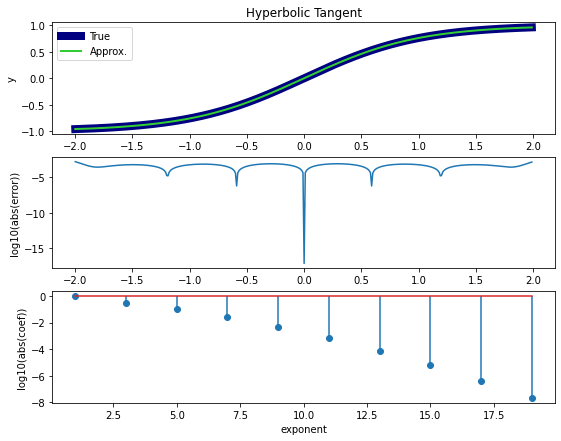

In [4]:
x = np.arange(-2, 2, 0.01)
y = polyval_cpu(alpha_coefs_float64, exponents, x)
y_true = np.tanh(x)

error = np.log10(np.abs(y_true - y))

fig, axs = plt.subplots(3, 1, figsize=(9,7))
axs[0].plot(x, np.tanh(x), linewidth=8, color='navy')
axs[0].plot(x, y, linewidth=2, color='limegreen')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('Hyperbolic Tangent')
axs[0].legend(('True', 'Approx.'))
axs[1].plot(x, error)
axs[1].set_xlabel('x')
axs[1].set_ylabel('log10(abs(error))')
axs[2].stem(exponents, np.log10(np.abs(alpha_coefs_float64)))
axs[2].set_xlabel('exponent')
axs[2].set_ylabel('log10(abs(coef))')